In [1]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
session_path = '../data/to/to3/to3_06052024'
session = MPOptoClass(session_path)

love


In [3]:
pre=50
post=200
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
#powers = session.getPowers(laser_bounds, num_powers=5, pre=pre, post=post)
powers = session.getPowers(laser_bounds, num_powers=2, pre=pre, post=post)

In [4]:
len(laser_bounds)

179

In [5]:
high_laser_bounds = laser_bounds[powers==5,:]
low_laser_bounds = laser_bounds[powers==2,:]

In [6]:
early_lasers = laser_bounds[:200]
late_lasers = laser_bounds[-200:]

In [7]:
CFA, THAL = session.smoother(bounds=high_laser_bounds, binsize=1, sigma=10, concat=False, smooth_type='causal')
CFA_ctrl, THAL_ctrl = session.smoother(bounds=ctrl_bounds, binsize=1, sigma=10, concat=False, smooth_type='causal')

CFA_low, THAL_low = session.smoother(bounds=low_laser_bounds, binsize=1, sigma=10, concat=False, smooth_type='causal')

KeyboardInterrupt: 

In [ ]:
CFA_early, THAL_late = session.smoother(bounds=high_laser_bounds, binsize=1, sigma=10, concat=False, smooth_type='causal')

CFA_low, THAL_low = session.smoother(bounds=low_laser_bounds, binsize=1, sigma=10, concat=False, smooth_type='causal')

In [ ]:
THAL_depth_mask = session.mask_depths(greater=450, less=1000)
new_thal = []
for trial in THAL:
    new_thal.append(trial[:, THAL_depth_mask])
    
THAL=new_thal
new_thal = []
for trial in THAL_ctrl:
    new_thal.append(trial[:, THAL_depth_mask])
    
THAL_ctrl=new_thal

new_thal = []
for trial in THAL_low:
    new_thal.append(trial[:, THAL_depth_mask])
THAL_low = new_thal
    

In [ ]:
CFA = np.array(CFA)
THAL = np.array(THAL)
CFA_low = np.array(CFA_low)
THAL_low = np.array(THAL_low)
CFA_ctrl = np.array(CFA_ctrl)
THAL_ctrl = np.array(THAL_ctrl)

In [ ]:
avgavg, avgsem = trial_sem(CFA)
low_avgavg, low_avgsem = trial_sem(CFA_low)

In [ ]:
fig, ax = plot_trial_sem(avgavg, avgsem, low_avgavg, low_avgsem, colors=['blue', 'orange'], labels=['2-power', '5-power'])
ax.set_title('CFA, 87 neurons')

In [ ]:
thal_avgavg, thal_avgsem = trial_sem(THAL)
thal_low_avgavg, thal_low_avgsem = trial_sem(THAL_low)

In [ ]:
fig, ax = plot_trial_sem(thal_avgavg, thal_avgsem, thal_low_avgavg, thal_low_avgsem, colors=['blue', 'orange'], labels=['2-power', '5-power'])
ax.set_title('mthal, 45 neurons')

In [ ]:
fig, ax = plot_trial_sem(avgavg, avgsem, thal_avgavg, thal_avgsem, colors=['blue', 'orange'], labels=['CFA', 'Mthal'])
ax.set_title('mthal, 45 neurons')

# to3, checking stuff

In [17]:
session_path = '../data/to/to5/to5_06202024'
session = MPOptoClass(session_path)

love


In [18]:
THAL_depth_mask = session.mask_depths(greater=300, less=1000)
new_train = []
for idx in np.arange(len(THAL_depth_mask)):
    if THAL_depth_mask[idx] == True:
        new_train.append(session.RFA['train'][idx])
session.RFA['train'] = new_train
session.num_RFA = len(new_train)

In [24]:
nlags=5
binsize=5
num_PCs=0
pre=nlags*binsize
post=19

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)

In [69]:
climb_bounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)

In [25]:
X_laser, Y_laser, PCs_laser = session.generate_trainset(laser_bounds, binsize, nlags, num_PCs)
cfa_mask, thal_mask = session.mask_input_region(X_laser, nlags, num_CFA=num_PCs)
X_cfa_laser = X_laser[:,cfa_mask]

In [26]:
y2, yhat2, h_cfa = wiener_kfolds(X_cfa_laser, Y_laser, c=(2,5))
print(weighted_r2(y2, yhat2))

4it [00:00, 17.75it/s]

0.46037267984642016


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


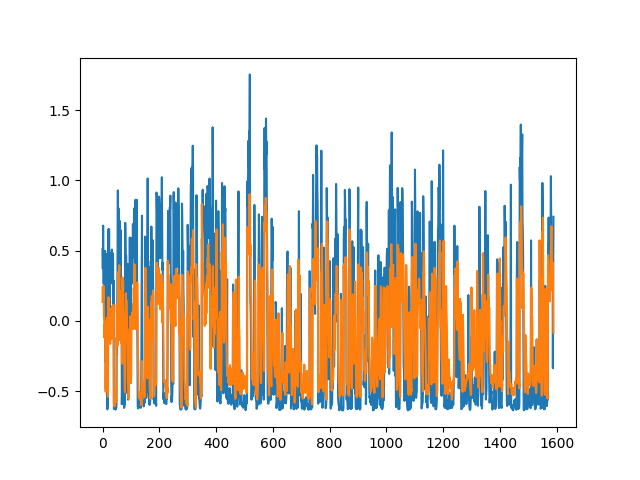

In [27]:
fig, ax = plt.subplots()
ax.plot(y2[:,0])
ax.plot(yhat2[:,0])

In [28]:
y, yhat, h = wiener_kfolds(X_laser, Y_laser, c=(2,5))

print(weighted_r2(y, yhat))
c, t= session.relative_input(h, X_laser, nlags, num_CFA=20)

4it [00:00,  7.55it/s]

0.4537083992505505


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


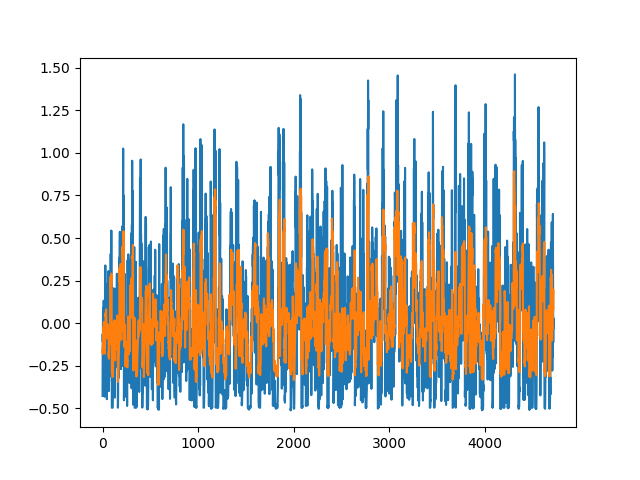

In [60]:
fig, ax = plt.subplots()
ax.plot(y[:,0])
ax.plot(yhat[:, 0])

In [39]:
yhat = test_wiener_filter(X_climb[:, cfa_mask], h_cfa)

In [41]:
yhat = test_wiener_filter(X_climb, h)

In [42]:
print(weighted_r2(Y_climb, yhat))

0.06476185323543006


In [26]:
X_laser.shape

(772, 4700)

In [28]:
X_cfa_laser.shape

(772, 1740)

In [25]:
print(weighted_r2(y, yhat))

0.11331140445133242


In [32]:
y, yhat, h_climb = wiener_kfolds(X_climb, Y_climb, c=(2,5))

c, t= session.relative_input(h_climb, X_climb, nlags, num_CFA=20)

4it [00:18,  4.75s/it]


In [33]:
np.log10(c/t)

0.45397875602052906

In [15]:
check = session.RFA['train']

In [12]:
THAL_depth_mask = session.mask_depths(greater=450, less=1000)

In [13]:
len(THAL_depth_mask)

148

In [16]:
len(check)

148

In [41]:
len(session.RFA['train'])

148

In [42]:
session.RFA['train'] = new_train

In [43]:
session.binner(binsize=10)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

In [37]:
new_train = []
for idx in np.arange(len(THAL_depth_mask)):
    if THAL_depth_mask[idx] == True:
        new_train.append(check[idx])

In [ ]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=False)

omit_lasers, omit_ctrls = session.adjustLaserBounds(pre, 200, only_climb=True)
climb_bounds = omitBoundInBounds(session.climbing_bounds, omit_lasers)
climb_bounds = omitBoundInBounds(climb_bounds, omit_ctrls)

powers = session.getPowers(laser_bounds, num_powers=5, pre=pre, post=post)

In [ ]:
all_laser_bounds = laser_bounds[powers!=5,:]

In [ ]:


check1 = bounds2Logical(climb_bounds)
check2 = bounds2Logical(laser_bounds, duration=len(check1))

In [ ]:
X_climb, Y_climb, PCs_climb = session.generate_trainset(climb_bounds, binsize, nlags, num_PCs)
h_climb = train_wiener_filter(X_climb, Y_climb)

In [ ]:
pow_lasers_bounds = laser_bounds[powers==5,:]

Y_test_list = []
Y_test_hat_list = []

Y_atest_list = []
Y_atest_hat_list = []

Y_ctest_list = []
Y_ctest_hat_list = []

for train_index, test_index in tqdm(leaveBoundOut(pow_lasers_bounds)):
    train_bounds = pow_lasers_bounds[train_index]
    all_bounds = np.vstack((all_laser_bounds, train_bounds))
    test_bounds = pow_lasers_bounds[test_index]
    
    X, Y, PCs = session.generate_trainset(train_bounds, binsize, nlags, num_PCs)
    X_test, Y_test = session.generate_testset(PCs, test_bounds, binsize, nlags, num_PCs)
    
    X_all, Y_all, PCs_all = session.generate_trainset(all_bounds, binsize, nlags, num_PCs)
    X_test_all, Y_test_all = session.generate_testset(PCs_all, test_bounds, binsize, nlags, num_PCs)
    
    X_test_climb, Y_test_climb = session.generate_testset(PCs_climb, test_bounds, binsize, nlags, num_PCs)
    
    h = train_wiener_filter(X, Y, c=(1,5))
    h_all = train_wiener_filter(X_all, Y_all, c=(1,5))
    
    Y_test_hat = test_wiener_filter(X_test, h)
    Y_test_list.append(Y_test)
    Y_test_hat_list.append(Y_test_hat)
    
    Y_atest_hat = test_wiener_filter(X_test_all, h_all)
    Y_atest_list.append(Y_test_all)
    Y_atest_hat_list.append(Y_atest_hat)
    
    Y_ctest_hat = test_wiener_filter(X_test_climb, h_climb)
    Y_ctest_list.append(Y_test_climb)
    Y_ctest_hat_list.append(Y_ctest_hat)
    
    
    

In [ ]:
temp1 = np.array(Y_test_list)
temp2 = np.array(Y_test_hat_list)

temp3 = np.array(Y_atest_list)
temp4 = np.array(Y_atest_hat_list)

In [ ]:
p = np.reshape(temp1, (temp1.shape[0]*temp1.shape[1], temp1.shape[2]))
phat = np.reshape(temp2, (temp2.shape[0]*temp2.shape[1], temp2.shape[2]))

p_all = np.reshape(temp3, (temp3.shape[0]*temp3.shape[1], temp3.shape[2]))
phat_all = np.reshape(temp4, (temp4.shape[0]*temp4.shape[1], temp4.shape[2]))

In [ ]:
ttemp

big_average = np.average(temp1, axis=(0,2))
test_average = np.average(temp2, axis=(0,2))
print(big_average.shape)
fig, ax = plt.subplots()
ax.plot(big_average)
ax.plot(test_average)


In [ ]:
print(weighted_r2(p, phat))
print(weighted_r2(p_all, phat_all))

In [ ]:
np.hstack(Y_test_list).shape

In [ ]:
p = np.hstack(Y_test_list)
phat = np.hstack(Y_test_hat)

In [ ]:
phat.shape

In [ ]:
print(weighted_r2(p, phat))

# test stability of lasers

In [383]:
session_path = '../data/to/to3/to3_06052024'
session = MPOptoClass(session_path)

love


In [384]:
#nlags = 20
binsize= 1
pre = 50
post=100
#num_PCs=20

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=False)
laser_bounds = omitBoundInBounds(laser_bounds, session.climbing_bounds)
#laser_bounds,_ = reBoundInBounds(restBounds, laser_bounds)
#ctrl_bounds,_ = reBoundInBounds(restBounds, ctrl_bounds)
#powers = session.getPowers(laser_bounds, num_powers=5, pre=pre, post=post)

#high_laser_bounds = laser_bounds[powers==5, :]

In [385]:
new_laser_bounds = []
for bound in laser_bounds:
    if bound[1] - bound[0] != 181:
        print('remove')
    else:
        new_laser_bounds.append(bound)

remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove
remove


In [386]:
laser_bounds = np.array(new_laser_bounds)

In [387]:
powers = session.getPowers(laser_bounds, num_powers=5, pre=pre, post=post)
high_laser_bounds = laser_bounds[powers>=3,:]

In [388]:
len(high_laser_bounds)

1330

In [465]:
laser_early = high_laser_bounds[500:700,:]
laser_late = high_laser_bounds[-200:,:]

In [466]:
_, THAL = session.smoother(binsize=50, sigma=500, concat=True, smooth_type='causal')

In [467]:
THAL.shape

(5561, 148)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


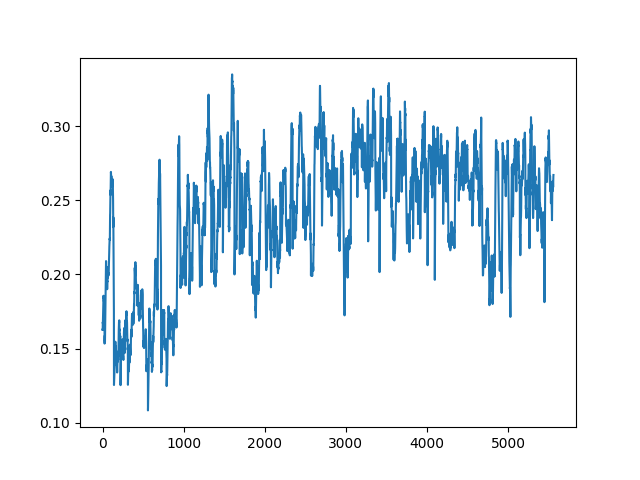

In [468]:
fig, ax = plt.subplots()
ax.plot(np.average(THAL, axis=1))

In [469]:
CFA_early, THAL_early = session.smoother(bounds=laser_early, binsize=1, sigma=10, concat=False, smooth_type='causal')
CFA_late, THAL_late = session.smoother(bounds=laser_late, binsize=1, sigma=10, concat=False, smooth_type='causal')

In [470]:
CFA_early = np.array(CFA_early) 
THAL_early = np.array(THAL_early) 

CFA_late  = np.array(CFA_late) 
THAL_late = np.array(THAL_late) 

#CFA_mask, THAL_mask = session.threshold_FRs(threshold=3, bounds=session.climbing_bounds)

#CFA_early = CFA_early[:,:,CFA_mask]
#THAL_early = THAL_early[:,:,THAL_mask]
#CFA_late = CFA_late[:,:,CFA_mask]
#THAL_late = THAL_late[:,:,THAL_mask]

In [471]:
THAL_depth_mask = session.mask_depths(greater=300, less=1000)

In [472]:
THAL_early = THAL_early[:,:,THAL_depth_mask]
THAL_late = THAL_late[:,:,THAL_depth_mask]

In [473]:
cfa_avg_early, cfa_avg_early_sem = trial_sem(CFA_early, pre_baseline=50)
cfa_avg_late, cfa_avg_late_sem = trial_sem(CFA_late, pre_baseline=50)

3.153943147539124
3.189243510913345


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


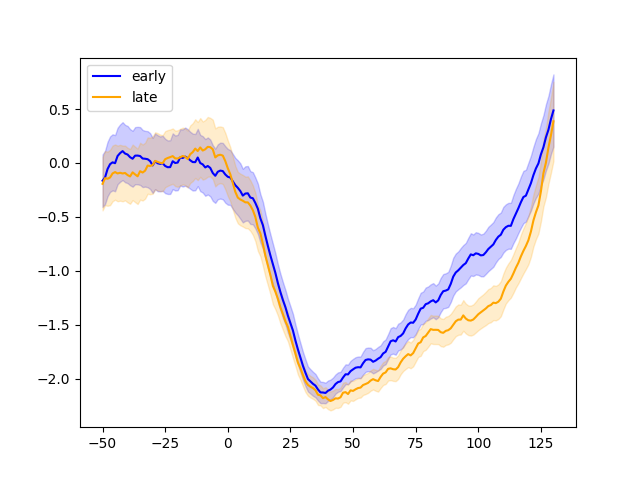

In [474]:
fig, ax = plot_trial_sem(cfa_avg_early, cfa_avg_early_sem, cfa_avg_late, cfa_avg_late_sem, colors=['blue', 'orange'], labels=['early', 'late'])

In [475]:
thal_avg_early, thal_avg_early_sem = trial_sem(THAL_early)
thal_avg_late, thal_avg_late_sem = trial_sem(THAL_late)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


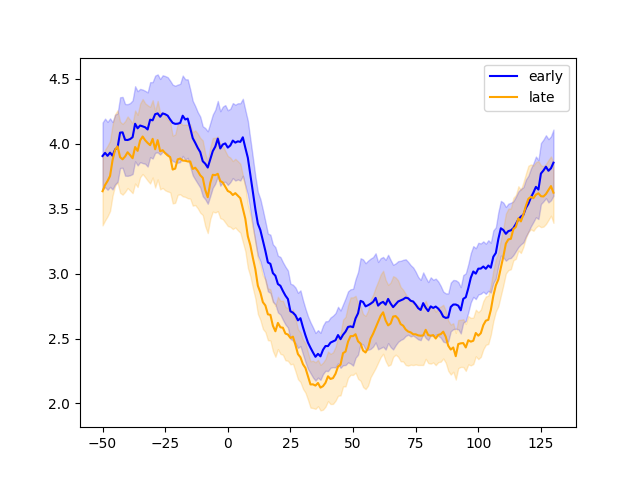

In [476]:
fig, ax = plot_trial_sem(thal_avg_early, thal_avg_early_sem, thal_avg_late, thal_avg_late_sem, colors=['blue', 'orange'], labels=['early', 'late'])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


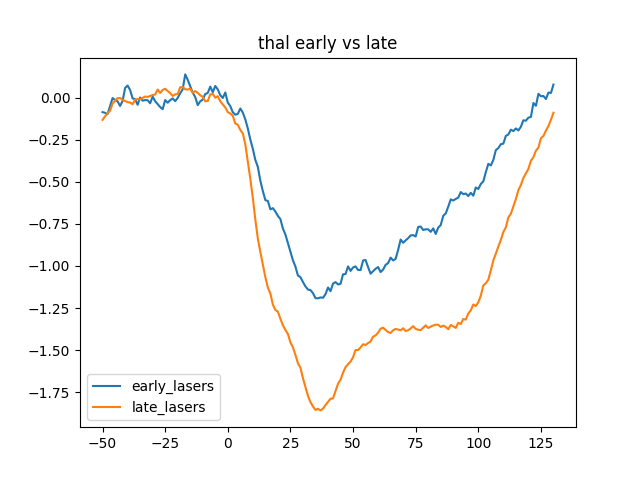

In [407]:
fig, ax = plt.subplots()
ax.plot(np.arange(-50,131), thal_avg_early - thal_bls_avg_early, label='early_lasers')
ax.plot(np.arange(-50,131), thal_avg_late -  thal_bls_avg_late, label='late_lasers')
ax.set_title('thal early vs late')
ax.legend()

In [12]:
cfa, thal = session.binner(binsize=100)

In [13]:
thal.shape

(36200, 148)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


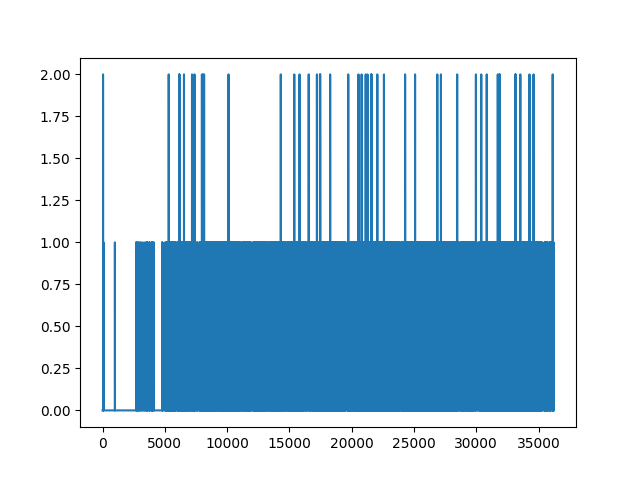

In [19]:
fig, ax = plt.subplots()
ax.plot(thal[:,20])

In [84]:
output=np.empty((3, thal.shape[1]))

In [85]:
splits = np.linspace(0, thal.shape[0],4, dtype=int)
for i in np.arange(3):
    output[i,:] = np.average(thal[splits[i]:splits[i+1],:], axis=0)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


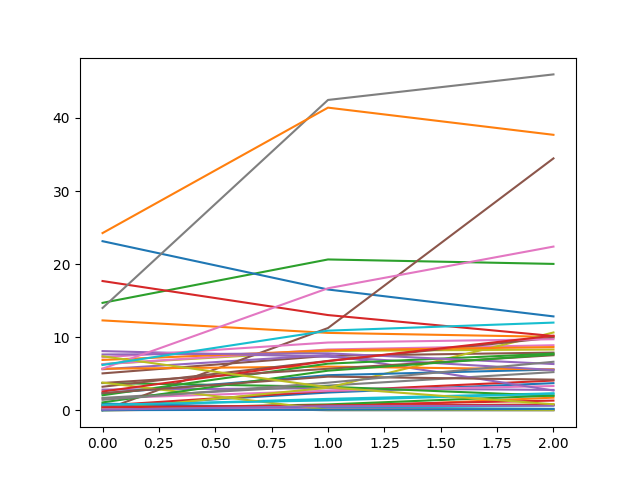

In [86]:
fig, ax = plt.subplots()
ax.plot(output[:,70:120]*10)

# to5

In [477]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [486]:
session_path = '../data/co/co10/co10_01232024'
session = MPOptoClass(session_path)

love


In [487]:
CFA, RFA = session.smoother(binsize=50, sigma=500, concat=True, smooth_type='causal')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


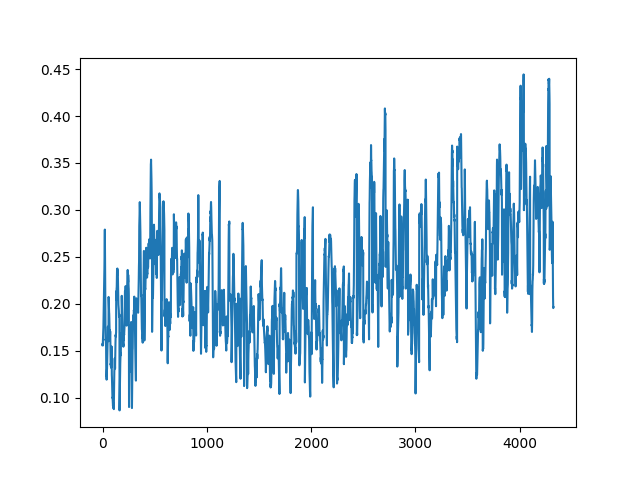

In [490]:
fig, ax = plt.subplots()
ax.plot(np.average(_, axis=1))

In [116]:
#nlags = 20
binsize= 1
pre = 50
post=100
#num_PCs=20

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=False)
powers = session.getPowers(laser_bounds, num_powers=5, pre=pre, post=post)

high_laser_bounds = laser_bounds[powers>=4, :]

removing first laser


In [117]:
len(high_laser_bounds)

31

In [118]:
laser_early = high_laser_bounds[:10,:]
laser_late = high_laser_bounds[-10:,:]

In [119]:
CFA_early, THAL_early = session.smoother(bounds=laser_early, binsize=1, sigma=10, concat=False, smooth_type='causal')
CFA_late, THAL_late = session.smoother(bounds=laser_late, binsize=1, sigma=10, concat=False, smooth_type='causal')

In [120]:
CFA_early = np.array(CFA_early) * 1000
THAL_early = np.array(THAL_early) * 1000

CFA_late  = np.array(CFA_late) * 1000
THAL_late = np.array(THAL_late) * 1000

#CFA_mask, THAL_mask = session.threshold_FRs(threshold=3, bounds=session.climbing_bounds)

#CFA_early = CFA_early[:,:,CFA_mask]
#THAL_early = THAL_early[:,:,THAL_mask]
#CFA_late = CFA_late[:,:,CFA_mask]
#THAL_late = THAL_late[:,:,THAL_mask]

In [121]:
cfa_avg_early = np.average(CFA_early, axis=(0,2))
thal_avg_early = np.average(THAL_early, axis=(0,2))

cfa_avg_late = np.average(CFA_late, axis=(0,2))
thal_avg_late = np.average(THAL_late, axis=(0,2))

cfa_bls_avg_early = np.average(CFA_early[:,:50,:])
thal_bls_avg_early = np.average(THAL_early[:,:50,:])

cfa_bls_avg_late = np.average(CFA_late[:,:50,:])
thal_bls_avg_late = np.average(THAL_late[:,:50,:])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'CFA modulation, first 30 climbing lasers vs last 30 climbing lasers')

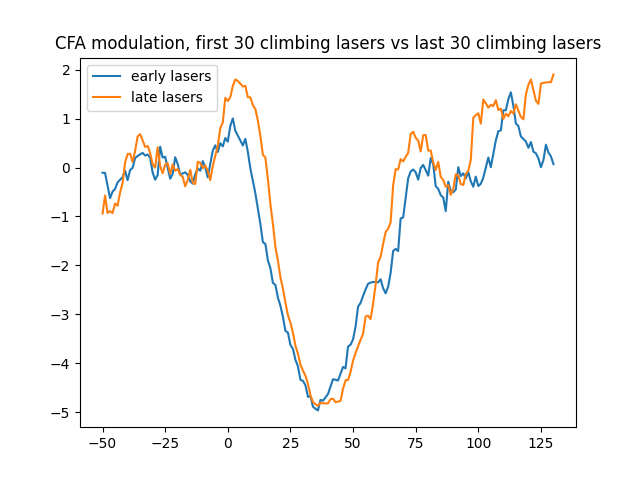

In [122]:
fig, ax = plt.subplots()
ax.plot(np.arange(-50,131), cfa_avg_early - cfa_bls_avg_early, label='early lasers')
ax.plot(np.arange(-50,131), cfa_avg_late -  cfa_bls_avg_late, label='late lasers')
ax.legend()
ax.set_title('CFA modulation, first 30 climbing lasers vs last 30 climbing lasers')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


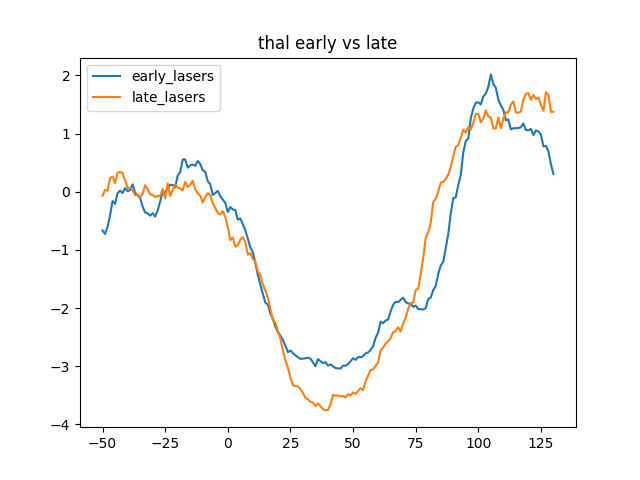

In [123]:
fig, ax = plt.subplots()
ax.plot(np.arange(-50,131), thal_avg_early - thal_bls_avg_early, label='early_lasers')
ax.plot(np.arange(-50,131), thal_avg_late -  thal_bls_avg_late, label='late_lasers')
ax.set_title('thal early vs late')
ax.legend()

In [2]:
session_path = '../data/to/to3/to3_06042024'
session = MPOptoClass(session_path)

love


In [147]:
keeps = np.logical_and(session.RFA['depth'] > 400, session.RFA['depth']  < 1000)

In [148]:
np.count_nonzero(keeps)

32

# diffreg

In [8]:
session_path = '../data/to/to3/to3_06042024'
session = MPOptoClass(session_path)

love


In [9]:
output = pload('../picklejar/to3_06052024_40PCs_10sw_SweepRegs.pickle')

In [10]:
h_all_list = []
laser_ar2_list = []
ctrl_ar2_list = []

h_climb_list = []
laser_cr2_list = []
ctrl_cr2_list = []

for o in output:
    a = o[0]
    c = o[1]
    
    h_all_list.append(a[0])
    laser_ar2_list.append(a[1])
    ctrl_ar2_list.append(a[2])
    
    h_climb_list.append(c[0])
    laser_cr2_list.append(c[1])
    ctrl_cr2_list.append(c[2])
    
    
    
    
    

In [11]:
inputs = pload('../picklejar/to3_06052024_40PCs_10sw_SweepRegs_inputs.pickle')

In [12]:
a = inputs[0]
c = inputs[1]

laser_aX = a[0]
ctrl_aX = a[1]

laser_cX = c[0]
ctrl_cX = c[1]

In [13]:
ctrl_drives_all = []
ctrl_drives_climb = []

laser_drives_all =[]
laser_drives_climb=[]
h_good_list = []
for idx in tqdm(range(len(h_all_list))):
    h_all = h_all_list[idx]
    C, T = session.relative_input(h_all, ctrl_aX, nlags=20, num_CFA=20) 
    ctrl_drives_all.append(np.log10(C/T))
    
    if ctrl_ar2_list[idx] > .15:
        if np.log10(C/T) > .62:
            h_good_list.append(h_all)
    h_climb = h_climb_list[idx]
    C, T = session.relative_input(h_climb, ctrl_cX, nlags=20, num_CFA=20) 
    ctrl_drives_climb.append(np.log10(C/T))
    
    h_all = h_all_list[idx]
    C, T = session.relative_input(h_all, laser_aX, nlags=20, num_CFA=20)
    laser_drives_all.append(np.log10(C/T))
    h_climb = h_climb_list[idx]
    C, T = session.relative_input(h_climb, laser_cX, nlags=20, num_CFA=20) 
    laser_drives_climb.append(np.log10(C/T))
    

100%|███████████████████| 225/225 [04:48<00:00,  1.28s/it]


In [14]:
len(h_good_list)

0

In [15]:
check=h_good_list[-1]

IndexError: list index out of range

In [16]:
_, thal_mask = session.mask_h_region(check, nlags=20, num_CFA=20)

NameError: name 'check' is not defined

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'check' is not defined

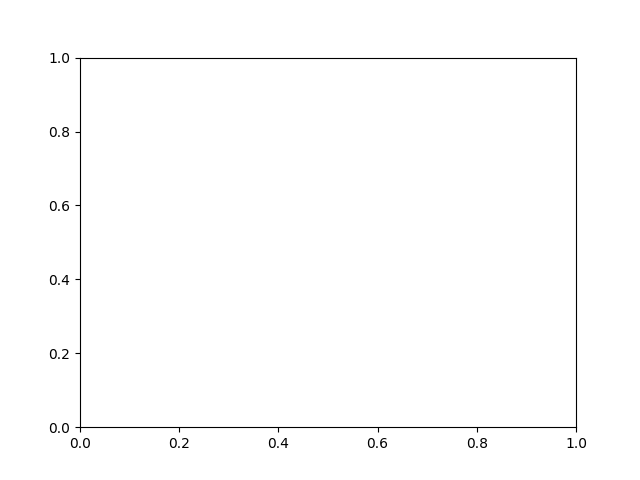

In [17]:
fig, ax = plt.subplots()
ax.scatter(np.arange(400), check[thal_mask,0])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


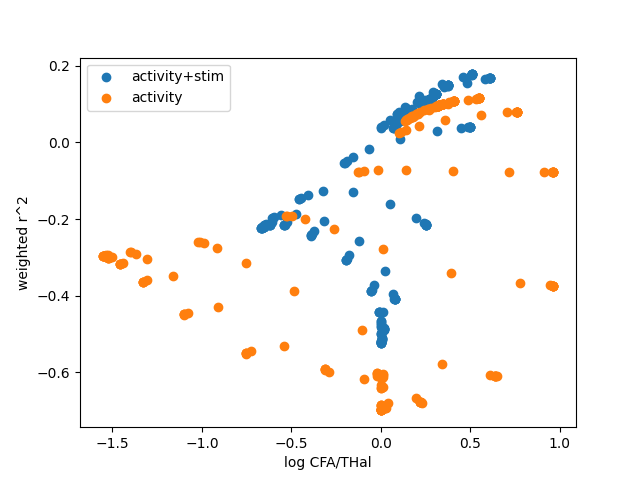

In [14]:
fig, ax = plt.subplots()
ax.scatter(ctrl_drives_all, ctrl_ar2_list, c='tab:blue', label='activity+stim')
ax.scatter(ctrl_drives_climb, ctrl_cr2_list, c='tab:orange', label='activity')
ax.set_xlabel('log CFA/THal')
ax.set_ylabel('weighted r^2')
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


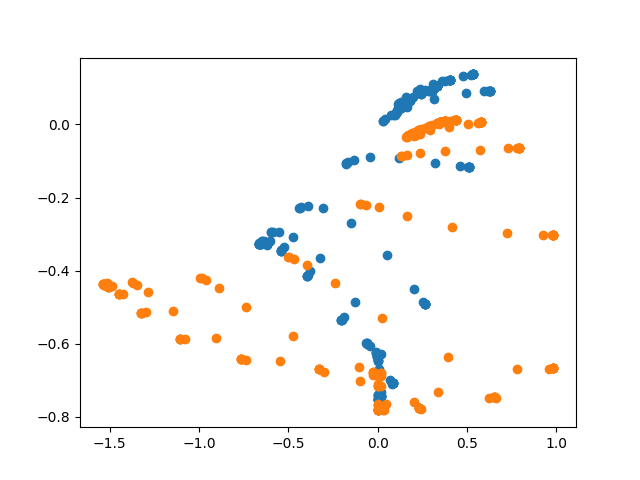

In [15]:
fig, ax = plt.subplots()
ax.scatter(laser_drives_all, laser_ar2_list)
ax.scatter(laser_drives_climb, laser_cr2_list)